# 1. Problem Definition

## Problem Statement

The goal of this project is to build a **machine learning classification model** that predicts whether a loan application will be **approved or rejected** based on the applicant's financial and personal information.

The dataset contains information about the applicant, their income, requested loan amount, credit score, assets, and other factors that may influence the loan approval decision.

## Objective

The objective is to predict the **`loan_status`** of a loan application using the available features.

- **Target variable:** `loan_status`
- **Problem type:** Binary Classification
- **Input features:**
  - `no_of_dependents`
  - `education`
  - `self_employed`
  - `income_annum`
  - `loan_amount`
  - `loan_term`
  - `cibil_score`
  - `residential_assets_value`
  - `commercial_assets_value`
  - `luxury_assets_value`
  - `bank_asset_value`

## Expected Outcome

The trained model should learn patterns from historical loan applications and predict whether a new loan application is likely to be:

- **Approved**
- **Rejected**

The model's performance will be evaluated using appropriate classification metrics such as **Accuracy, Precision, Recall, F1-Score, and Confusion Matrix**.

# 2. Import Libraries

In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42) # ssetting the random seed

# 3. Load the Dataset

In [183]:
df=pd.read_csv("/content/loan_approval_dataset.csv",index_col=0)

# 4. Exploratory Data Analysis (EDA)

## 4.1 Dataset Overview

In [184]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
loan_id,,,,,,,,,,,,
1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected


In [185]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [186]:
## get rid of leading spaces at columns names
df.columns = df.columns.str.strip()

In [187]:
df.shape

(4269, 12)

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4269 entries, 1 to 4269
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 433.6+ KB


In [189]:
df.nunique()

,0
no_of_dependents,6
education,2
self_employed,2
income_annum,98
loan_amount,378
loan_term,10
cibil_score,601
residential_assets_value,278
commercial_assets_value,188
luxury_assets_value,379


### observation
`education`and `self employed` are catigorical columns and the other columns are continues

In [190]:
df.isna().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


### Observation
There are no missing data

In [191]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


###

In [192]:
df=df.drop_duplicates()

## 4.2 Target Distribution

In [193]:
df["loan_status"].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [194]:
df["loan_status"].value_counts(normalize=True)

,proportion
loan_status,
Approved,0.62216
Rejected,0.37784


### Observation

The target variable is moderately imbalanced, with 62.2% of applications being
approved and 37.8% being rejected. However, the imbalance is not severe enough
to require resampling at this stage. Therefore, the original class distribution
will be used initially, while precision, recall, and F1-score will be considered
alongside accuracy when evaluating the models.

## 4.3 Numerical Features Analysis

In [195]:
df.education.value_counts()

,count
education,
Graduate,2144
Not Graduate,2125


In [196]:
df.groupby("education").loan_status.value_counts(normalize=True)

education     loan_status
Graduate      Approved       0.624534
              Rejected       0.375466
Not Graduate  Approved       0.619765
              Rejected       0.380235
Name: proportion, dtype: float64

In [197]:
df.self_employed.value_counts()

,count
self_employed,
Yes,2150
No,2119


In [198]:
df.groupby("self_employed").loan_status.value_counts(normalize=True)

self_employed  loan_status
No             Approved       0.621992
               Rejected       0.378008
Yes            Approved       0.622326
               Rejected       0.377674
Name: proportion, dtype: float64

In [199]:
pd.crosstab(df["education"],df["self_employed"])

self_employed,No,Yes
education,,
Graduate,1089,1055
Not Graduate,1030,1095


In [200]:
df.groupby(["education","self_employed"]).loan_status.value_counts(normalize=True)

education     self_employed  loan_status
Graduate      No             Approved       0.625344
                             Rejected       0.374656
              Yes            Approved       0.623697
                             Rejected       0.376303
Not Graduate  No             Approved       0.618447
                             Rejected       0.381553
              Yes            Approved       0.621005
                             Rejected       0.378995
Name: proportion, dtype: float64

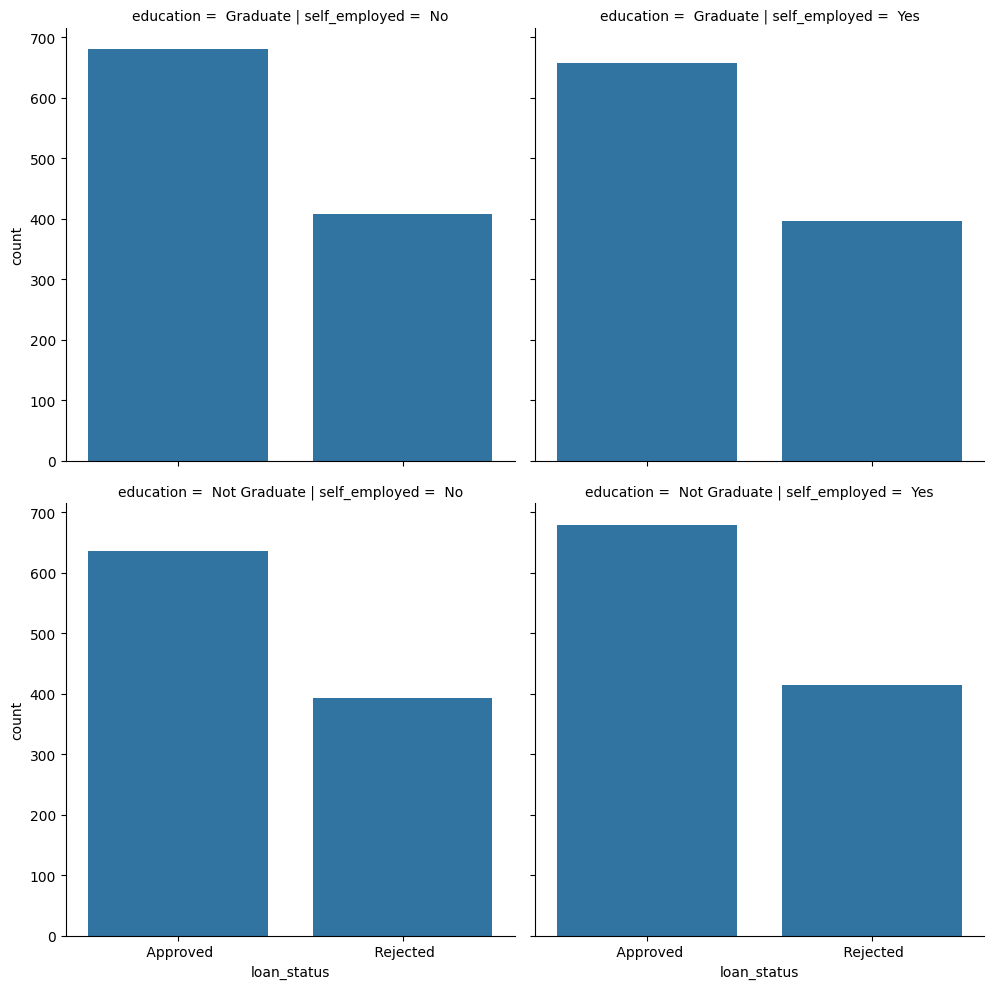

In [201]:
sns.catplot(data=df,col="self_employed",row="education",x="loan_status",kind="count")

## 4.4 Categorical Features Analysis

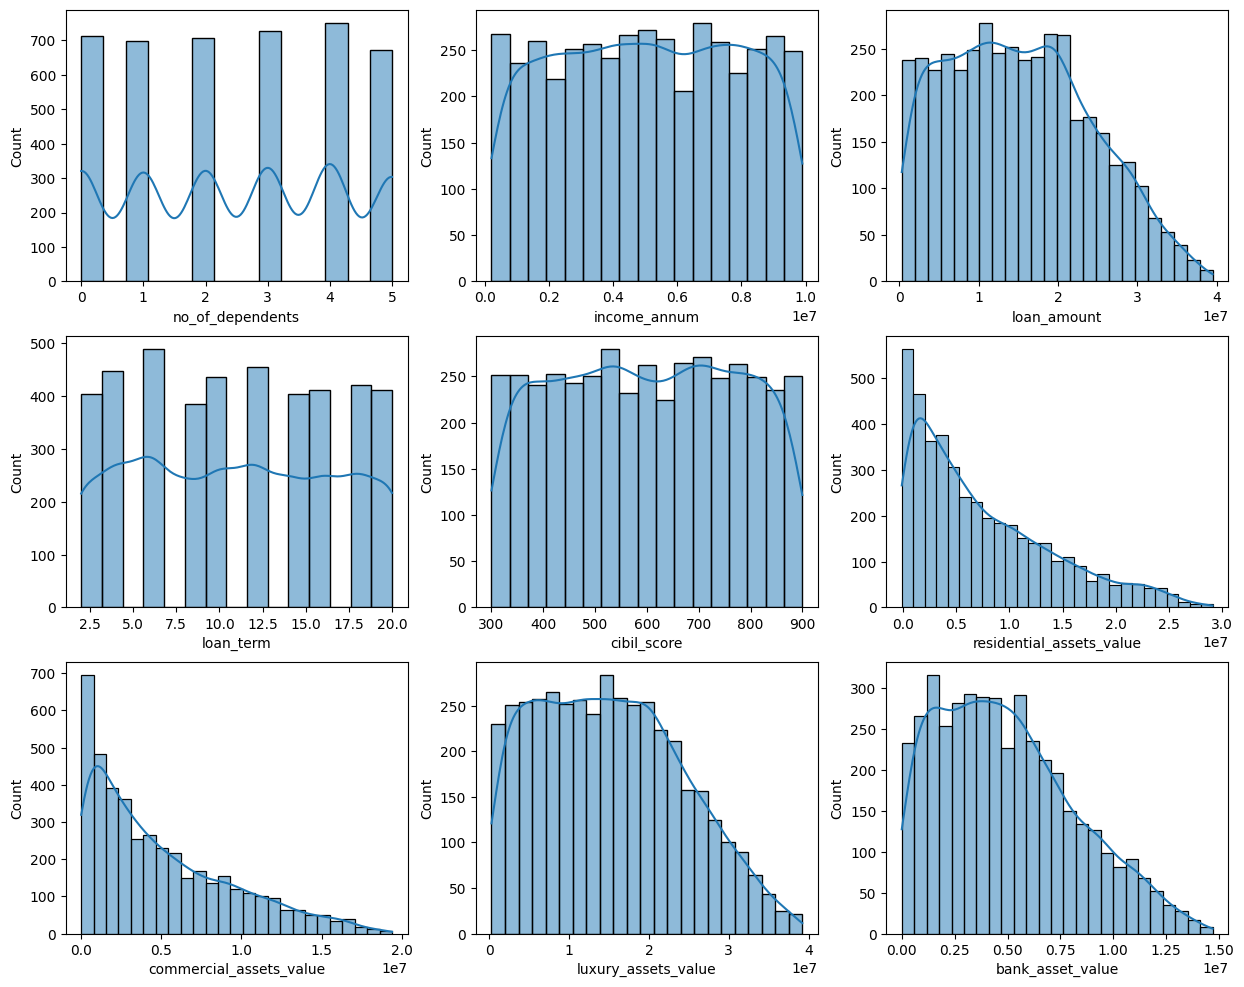

In [202]:

continues_value_cols_hist=["no_of_dependents","income_annum",
                      "loan_amount","loan_term",
                      "cibil_score","residential_assets_value",
                      "commercial_assets_value","luxury_assets_value",
                      "bank_asset_value"]
fig,axes=plt.subplots(nrows=3,ncols=3,figsize=(15,12))
axes=axes.flatten()
for i,ax in enumerate(axes):
  sns.histplot(data=df,x=continues_value_cols_hist[i],ax=ax,kde=True)
plt.show()

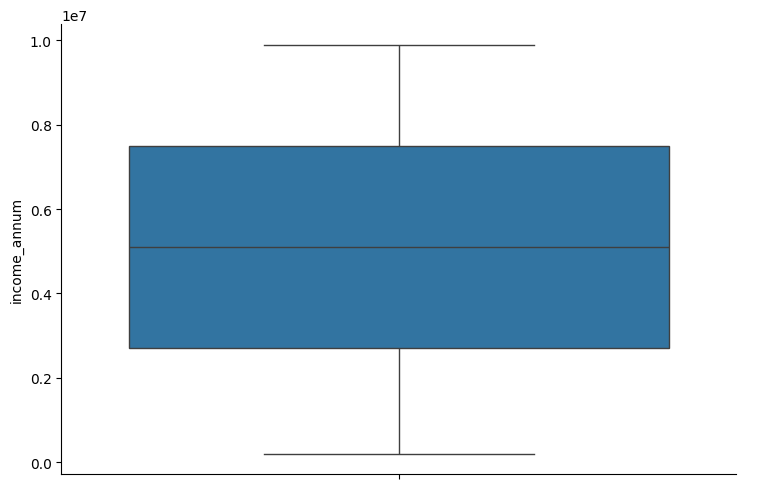

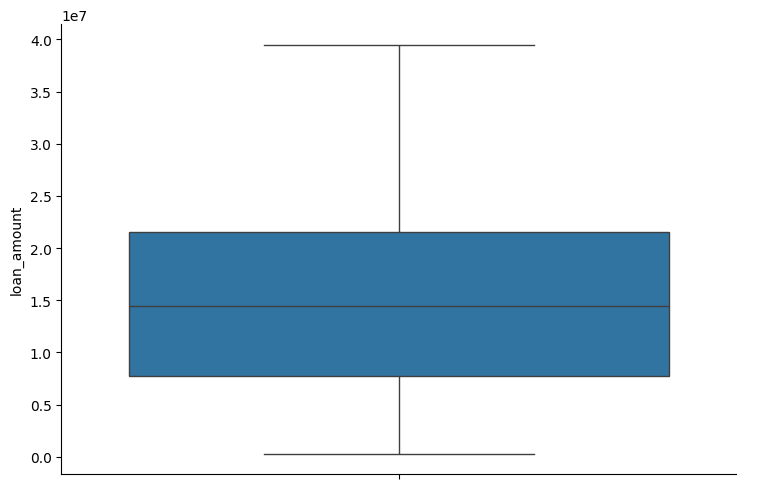

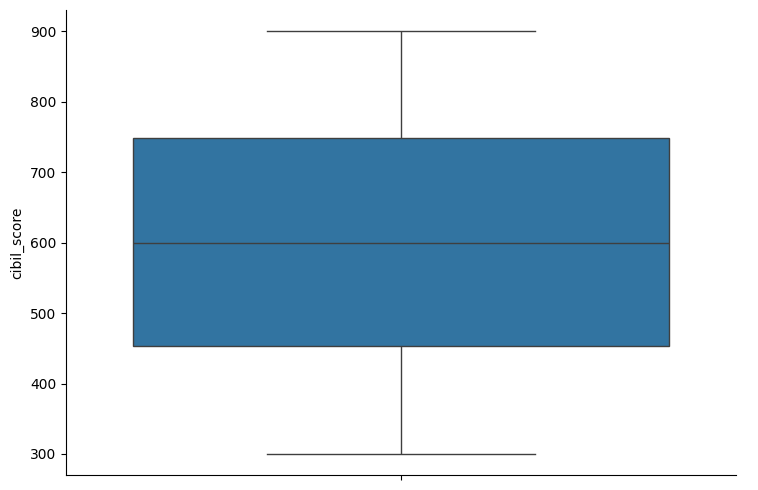

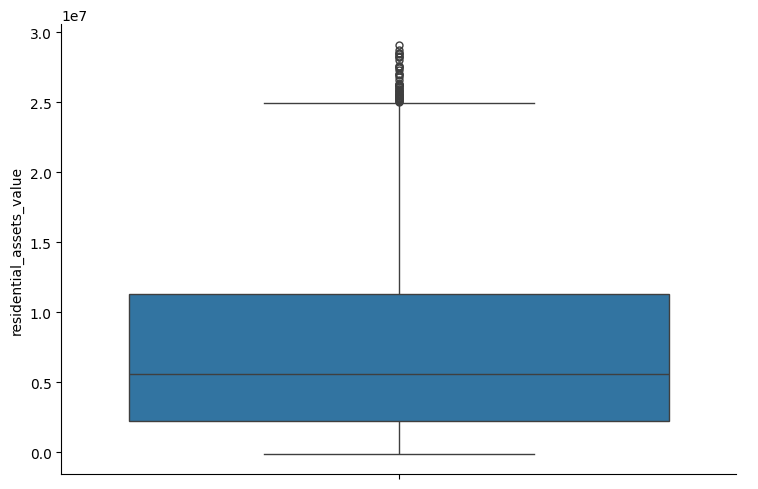

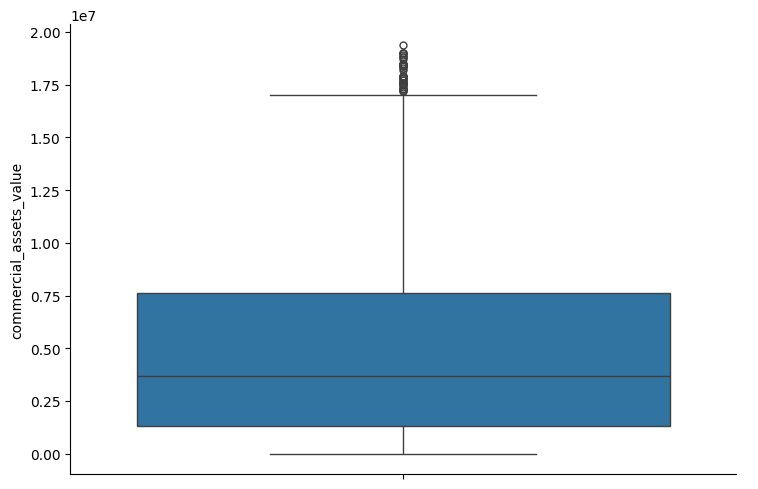

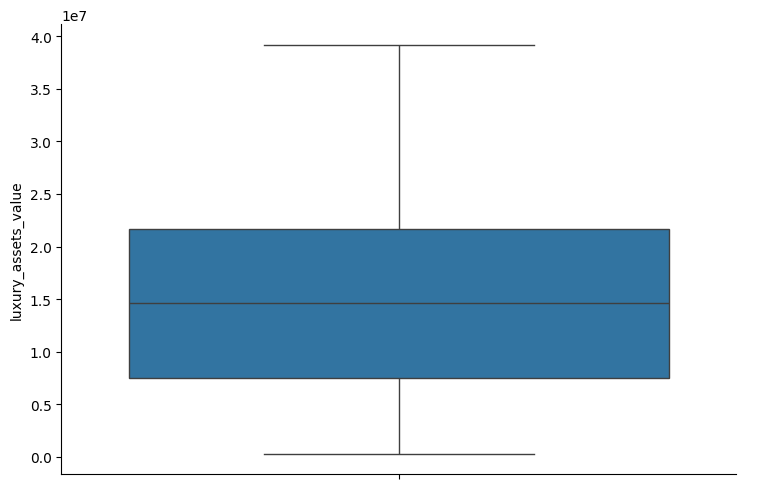

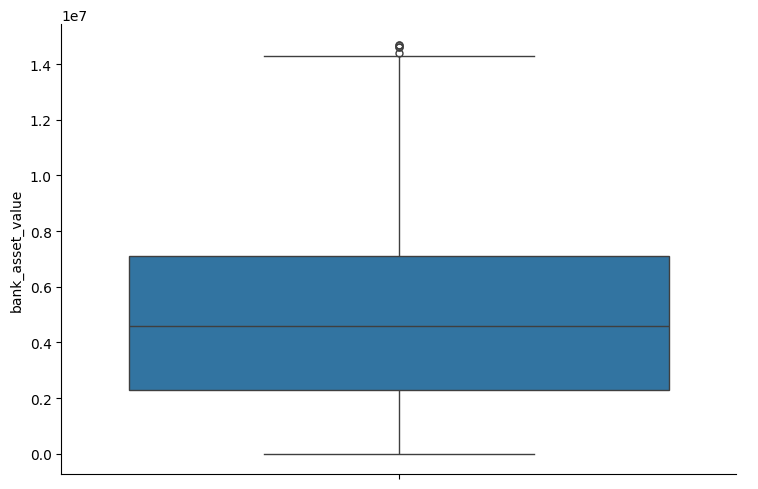

In [203]:
continues_value_cols_boxplot=["income_annum","loan_amount",
                      "cibil_score","residential_assets_value",
                      "commercial_assets_value","luxury_assets_value",
                      "bank_asset_value"]
for i in range(len(continues_value_cols_boxplot)):
  sns.catplot(data=df,y=continues_value_cols_boxplot[i],kind="box",height=5,aspect=1.5
              )
plt.show()

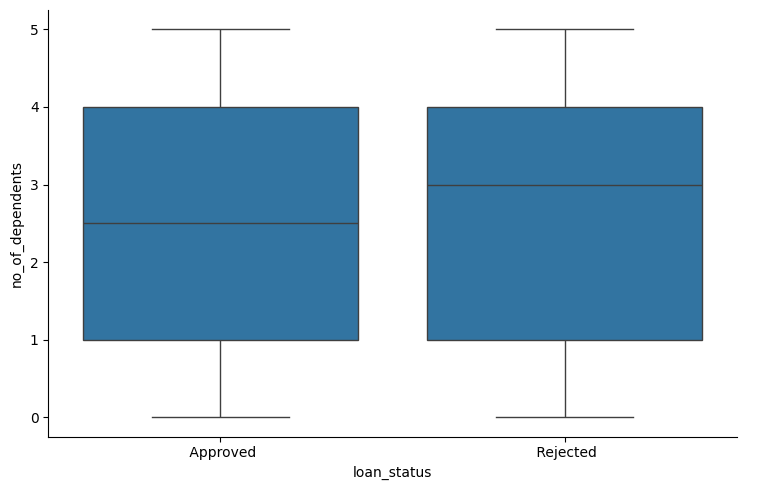

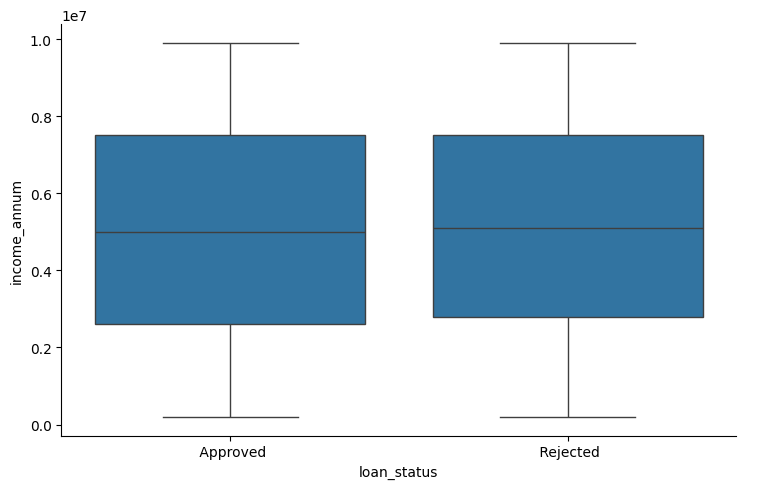

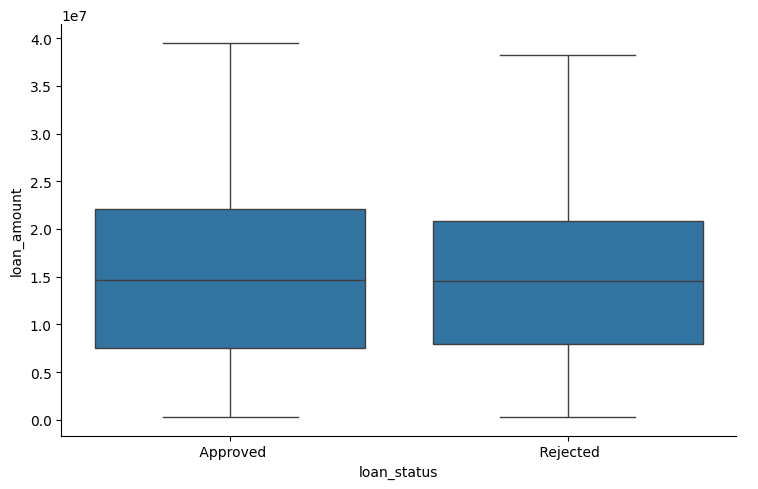

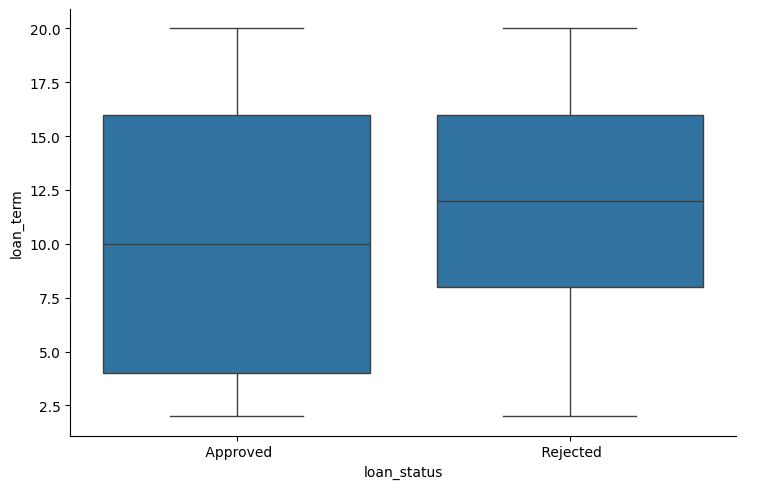

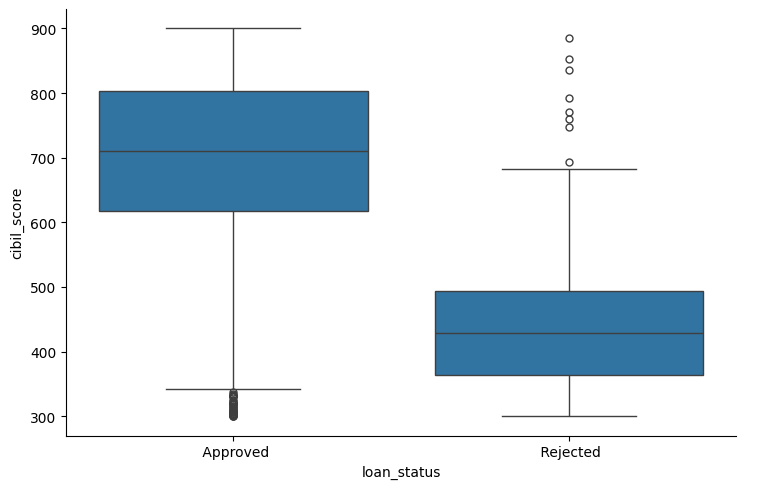

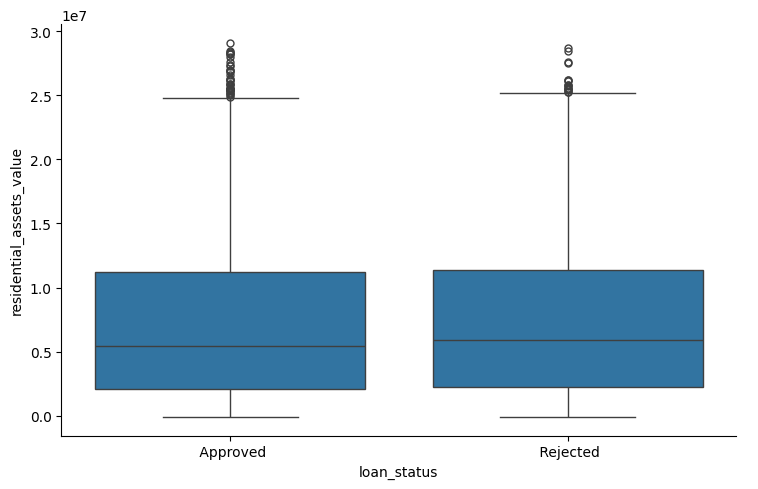

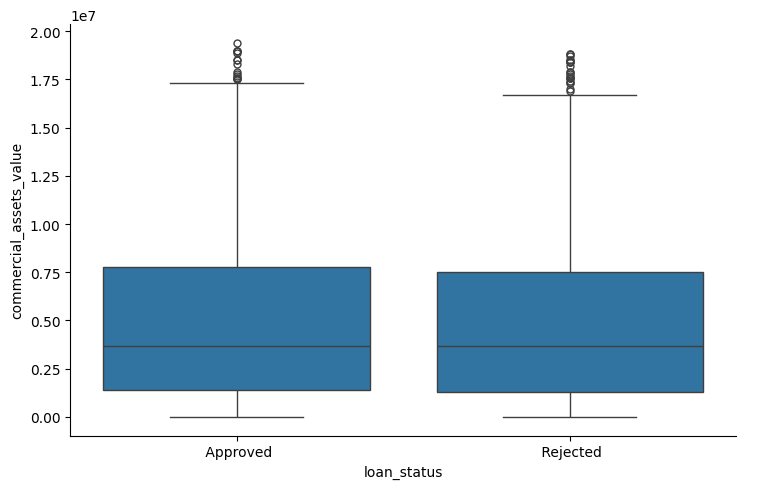

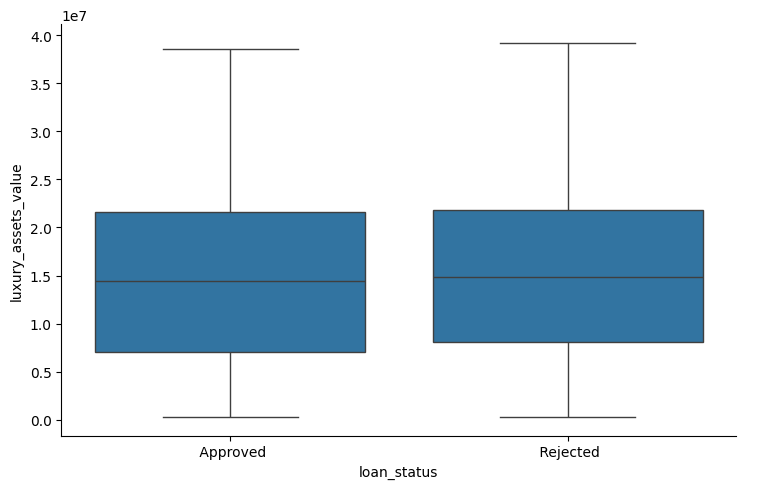

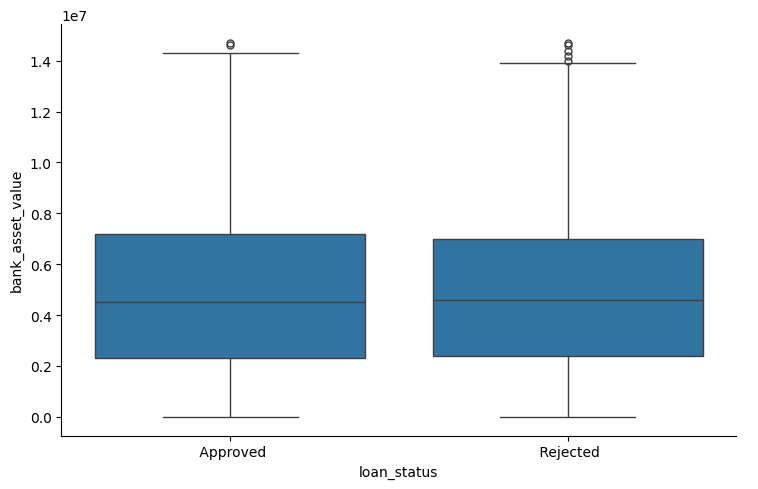

In [204]:

continues_value_cols_hist=["no_of_dependents","income_annum",
                      "loan_amount","loan_term",
                      "cibil_score","residential_assets_value",
                      "commercial_assets_value","luxury_assets_value",
                      "bank_asset_value"]
for i in range(len(continues_value_cols_hist)):
  sns.catplot( data = df, x='loan_status', y=continues_value_cols_hist[i], kind='box',height=5,aspect=1.5 )
plt.show()

# 5. Feature Engineering

In [205]:
df.nunique()

,0
no_of_dependents,6
education,2
self_employed,2
income_annum,98
loan_amount,378
loan_term,10
cibil_score,601
residential_assets_value,278
commercial_assets_value,188
luxury_assets_value,379


In [206]:
df["annual_loan_burden"]=df.loan_amount/df.loan_term

In [207]:
df["loan_to_income"]=df.loan_amount/df.income_annum

In [208]:
df["total_assests"]=df.residential_assets_value+df.luxury_assets_value+df.bank_asset_value+df.commercial_assets_value

In [209]:
df["loan_to_total_assests"]=df.loan_amount/df.total_assests

In [210]:
df["total_assests_to_income"]=df.total_assests/df.income_annum

In [211]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,annual_loan_burden,loan_to_income,total_assests,loan_to_total_assests,total_assests_to_income
loan_id,,,,,,,,,,,,,,,,,
1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,2.491667e+06,3.114583,50700000,0.589744,5.281250
2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,1.525000e+06,2.975610,17000000,0.717647,4.146341
3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,1.485000e+06,3.263736,57700000,0.514731,6.340659
4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,3.837500e+06,3.743902,52700000,0.582543,6.426829
5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,1.210000e+06,2.469388,55000000,0.440000,5.612245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected,1.916667e+05,2.300000,7400000,0.310811,7.400000
4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved,5.650000e+05,3.424242,20000000,0.565000,6.060606
4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected,1.327778e+06,3.676923,39000000,0.612821,6.000000


# 6. Data preprocessing

In [212]:
df.education=df.education.str.strip().map({"Graduate":1,"Not Graduate":0})
df.self_employed=df.self_employed.str.strip().map({"Yes":1,"No":0})
df.loan_status=df.loan_status.str.strip().map({"Approved":1,"Rejected":0})


In [213]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,annual_loan_burden,loan_to_income,total_assests,loan_to_total_assests,total_assests_to_income
loan_id,,,,,,,,,,,,,,,,,
1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,2.491667e+06,3.114583,50700000,0.589744,5.281250
2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1.525000e+06,2.975610,17000000,0.717647,4.146341
3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1.485000e+06,3.263736,57700000,0.514731,6.340659
4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.837500e+06,3.743902,52700000,0.582543,6.426829
5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1.210000e+06,2.469388,55000000,0.440000,5.612245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1.916667e+05,2.300000,7400000,0.310811,7.400000
4266,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,5.650000e+05,3.424242,20000000,0.565000,6.060606
4267,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,1.327778e+06,3.676923,39000000,0.612821,6.000000


In [214]:
df.isna().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


# 7. Correlation between columns

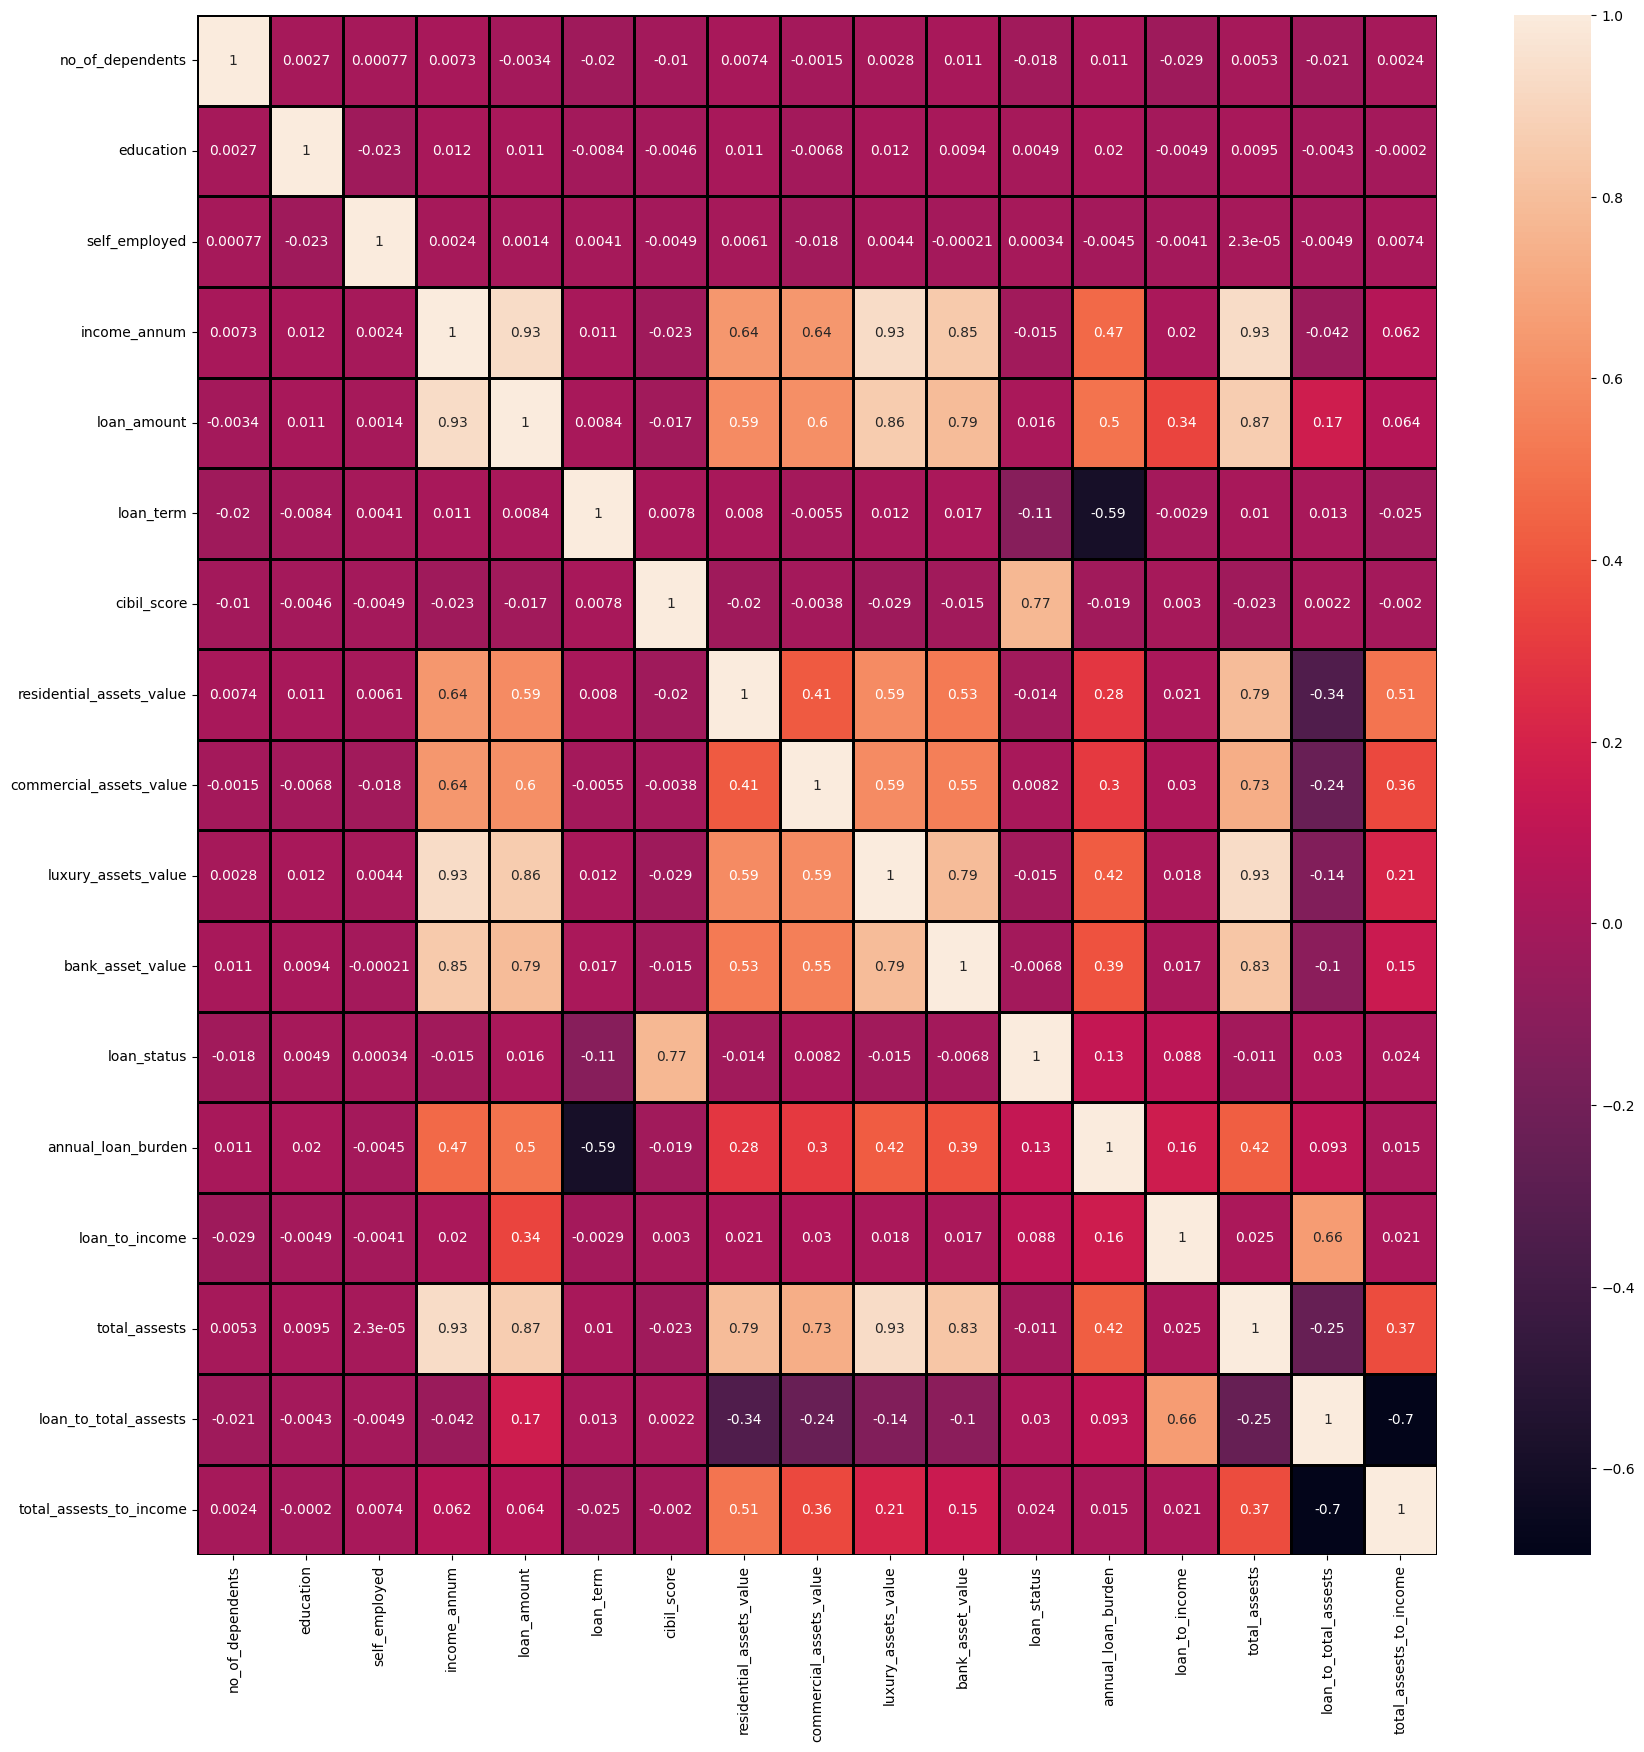

In [215]:
fig,ax=plt.subplots(figsize=(20,20))
sns.heatmap(df.corr(),annot =True,linewidths=1.0,ax=ax,linecolor="black")
plt.show()

# 8. splitting data

In [216]:
x=df.drop("loan_status",axis=1)
y=df["loan_status"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3
                                               ,random_state=42,stratify=y,shuffle=True)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2988, 16), (1281, 16), (2988,), (1281,))

# 9. Min-Max Normalization

In [217]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
x_train_transformed=min_max_scaler.fit_transform(x_train)
x_test_transformed=min_max_scaler.transform(x_test)

# 10. Train ML Models

In [245]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
linear_svc=LinearSVC()
svc_rbf=SVC(kernel="rbf")
log_reg = LogisticRegression(random_state=42)
random_forest=RandomForestClassifier(random_state=42)
XGB_clf=XGBClassifier(random_state=42)
knn=KNeighborsClassifier()


In [219]:
log_reg_param_grid = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': 10**np.random.uniform(-3, 2, size=100)
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': 10**np.random.uniform(-3, 2, size=100),
        'l1_ratio': [0.2, 0.5, 0.8]  # Only used when penalty='elasticnet'
    }
]

In [230]:
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [257]:
from scipy.stats import loguniform, randint

linear_svc_param_grid = [
    {
        "penalty": ["l2"],
        "loss": ["hinge", "squared_hinge"],
        "C": loguniform(1e-3, 1e2),
        "dual": [True],
        "max_iter":  [50000]
    },

    {
        "penalty": ["l1", "l2"],
        "loss": ["squared_hinge"],
        "C": loguniform(1e-3, 1e2),
        "dual": [False],
        "max_iter": [50000]
    }
]

In [253]:
SVC_rbf_param_grid = {
    "C": loguniform(1e-3, 1e2),
    "gamma": loguniform(1e-3, 1e2)
}

In [223]:
rng = np.random.default_rng(seed=42)
radom_forest_param_dist = {
   "n_estimators": rng.integers(100, 500, size=50),
    "max_depth": rng.integers(5, 30, size=50),
    "min_samples_split": rng.integers(2, 20, size=50),
    "min_samples_leaf": rng.integers(1, 10, size=50),
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True]
}

In [224]:
from scipy.stats import randint, uniform, loguniform

XGB_clf_param_dist = {
    "n_estimators": randint(100, 800),

    "learning_rate": loguniform(0.01, 0.3),

    "max_depth": randint(2, 10),

    "min_child_weight": randint(1, 15),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4),

    "gamma": loguniform(0.001, 10),

    "reg_alpha": loguniform(0.001, 10),

    "reg_lambda": loguniform(0.01, 100)
}

In [227]:
from sklearn.model_selection import RandomizedSearchCV
def Do_RandomizedSearchCV(model,params,x_train,y_train,Evaluation_Matrix,n_iter):
  model_RandomizedSearchCV=RandomizedSearchCV(model,params,cv=3,n_jobs=-1,scoring=Evaluation_Matrix,n_iter=n_iter,random_state=42)
  model_RandomizedSearchCV.fit(x_train,y_train)
  return ("best model params",model_RandomizedSearchCV.best_params_)



In [228]:
Do_RandomizedSearchCV(log_reg,log_reg_param_grid,x_train_transformed,y_train,"f1",200)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


('best model params',
 {'solver': 'saga',
  'penalty': 'l1',
  'l1_ratio': 0.2,
  'C': np.float64(0.5970408652384319)})

In [232]:
Do_RandomizedSearchCV(knn,knn_param_grid,x_train_transformed,y_train,"f1",50)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


('best model params',
 {'weights': 'distance', 'n_neighbors': 31, 'metric': 'manhattan'})

In [258]:
Do_RandomizedSearchCV(linear_svc,linear_svc_param_grid,x_train_transformed,y_train,"f1",200)

('best model params',
 {'C': np.float64(16.63664324117345),
  'dual': True,
  'loss': 'hinge',
  'max_iter': 50000,
  'penalty': 'l2'})

In [254]:
Do_RandomizedSearchCV(svc_rbf,SVC_rbf_param_grid,x_train_transformed,y_train,"f1",200)

('best model params',
 {'C': np.float64(89.64492537002859),
  'gamma': np.float64(0.11563475499641605)})

In [255]:
Do_RandomizedSearchCV(random_forest,radom_forest_param_dist,x_train_transformed,y_train,"f1",200)

('best model params',
 {'n_estimators': np.int64(280),
  'min_samples_split': np.int64(9),
  'min_samples_leaf': np.int64(3),
  'max_features': 0.5,
  'max_depth': np.int64(16),
  'bootstrap': True})

In [260]:
Do_RandomizedSearchCV(XGB_clf,XGB_clf_param_dist,x_train_transformed,y_train,"f1",400)

('best model params',
 {'colsample_bytree': np.float64(0.6881953738756426),
  'gamma': np.float64(1.1218415934712425),
  'learning_rate': np.float64(0.06328422257098237),
  'max_depth': 9,
  'min_child_weight': 1,
  'n_estimators': 371,
  'reg_alpha': np.float64(0.002059791517209845),
  'reg_lambda': np.float64(1.5065648701963434),
  'subsample': np.float64(0.8837283313890438)})

In [264]:
linear_svc=LinearSVC(C= np.float64(16.63664324117345),
  dual= True,
  loss= 'hinge',
  max_iter= 50000,
  penalty= 'l2')

svc_rbf=SVC(kernel="rbf",C= np.float64(89.64492537002859),
  gamma= np.float64(0.11563475499641605))

log_reg = LogisticRegression(random_state=42,solver= 'saga',
  penalty= 'l1',
  l1_ratio= 0.2,
  C= np.float64(0.5970408652384319))

random_forest=RandomForestClassifier(random_state=42,n_estimators= np.int64(280),
  min_samples_split= np.int64(9),
  min_samples_leaf= np.int64(3),
  max_features= 0.5,
  max_depth= np.int64(16),
  bootstrap= True)

XGB_clf=XGBClassifier(random_state=42,
  colsample_bytree= np.float64(0.6881953738756426),
  gamma= np.float64(1.1218415934712425),
  learning_rate= np.float64(0.06328422257098237),
  max_depth= 9,
  min_child_weight= 1,
  n_estimators= 371,
  reg_alpha= np.float64(0.002059791517209845),
  reg_lambda= np.float64(1.5065648701963434),
  subsample= np.float64(0.8837283313890438))

knn=KNeighborsClassifier(weights= 'distance', n_neighbors= 31, metric= 'manhattan')

Models_info=[
    ("log_reg",log_reg),
    ("linear_svc",linear_svc),
    ("svc_rbf",svc_rbf),
    ("knn",knn),
    ("random_forest",random_forest),
    ("XGB_clf",XGB_clf)
]

# 11. Evaluate Models

In [266]:
# Evaluation Models
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import ConfusionMatrixDisplay

def View_Results( dataset_name,y_true,y_preds):
  print(f"dataset :{dataset_name}")
  print(f"Accuracy Score : {accuracy_score(y_true,y_preds)}")
  print(f"F1 Score : {f1_score(y_true,y_preds)}")
  print(f"Recall Score : {recall_score(y_true,y_preds)}")
  print(f"precision Score : {precision_score(y_true,y_preds)}")
  ConfusionMatrixDisplay.from_predictions(y_true,y_preds)
  plt.show()
  print("------------------------------------------")


def Evaluate_Model(Models_info,x_train,y_train
                   ,x_test=None,y_test=None):
  for Model in Models_info:
    Model_name=Model[0]
    Model=Model[1]
    Model.fit(x_train,y_train)
    y_train_predictions=Model.predict(x_train)
    print(f"{Model_name}")
    View_Results( "Traning Dataset",y_train,y_train_predictions)
    if x_test is not None:
      y_test_predictions=Model.predict(x_test)
      View_Results( "Test Dataset",y_test,y_test_predictions)




/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


log_reg
dataset :Traning Dataset
Accuracy Score : 0.9253681392235609
F1 Score : 0.9401342281879195
Recall Score : 0.9419042495965573
precision Score : 0.9383708467309754


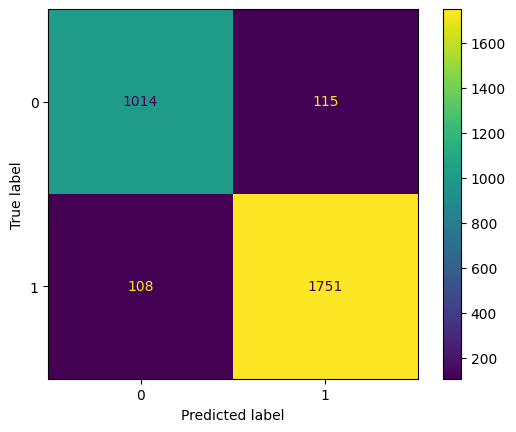

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.9281811085089774
F1 Score : 0.9425717852684145
Recall Score : 0.9473023839397742
precision Score : 0.937888198757764


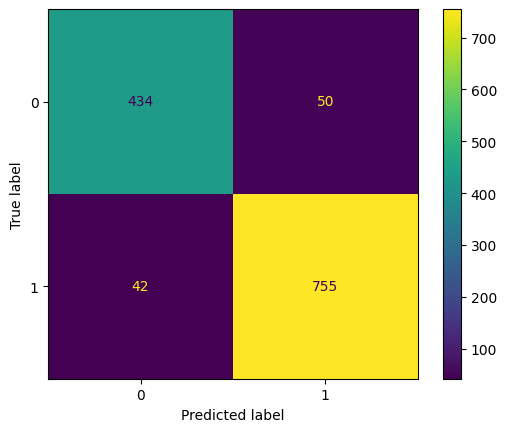

------------------------------------------
linear_svc
dataset :Traning Dataset
Accuracy Score : 0.927710843373494
F1 Score : 0.941747572815534
Recall Score : 0.9392146315223239
precision Score : 0.9442942130881558


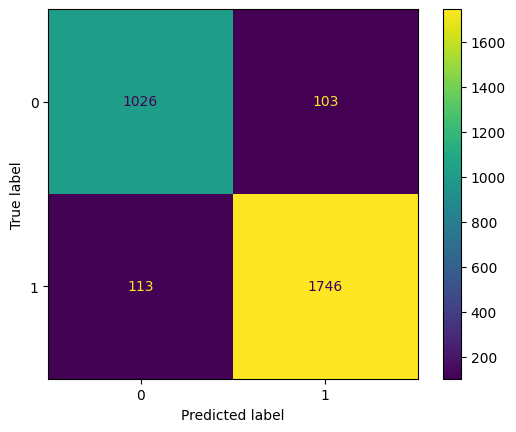

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.9328649492583919
F1 Score : 0.9458438287153652
Recall Score : 0.9422835633626098
precision Score : 0.9494310998735778


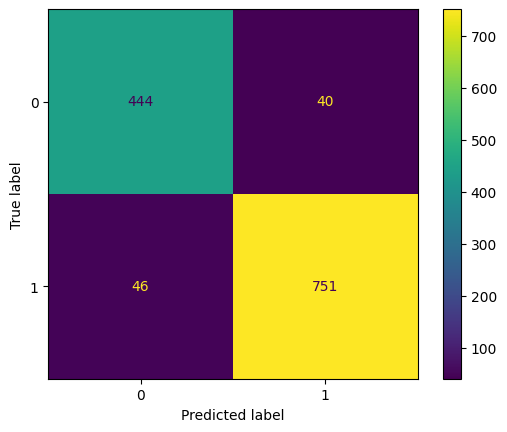

------------------------------------------
svc_rbf
dataset :Traning Dataset
Accuracy Score : 0.9675368139223561
F1 Score : 0.9739177198171551
Recall Score : 0.9741796664873588
precision Score : 0.9736559139784946


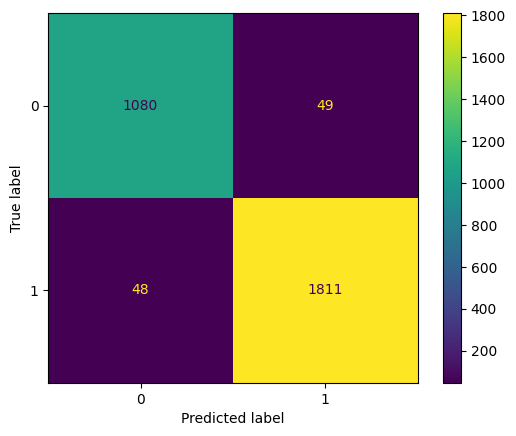

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.9461358313817331
F1 Score : 0.9567398119122257
Recall Score : 0.9573400250941029
precision Score : 0.956140350877193


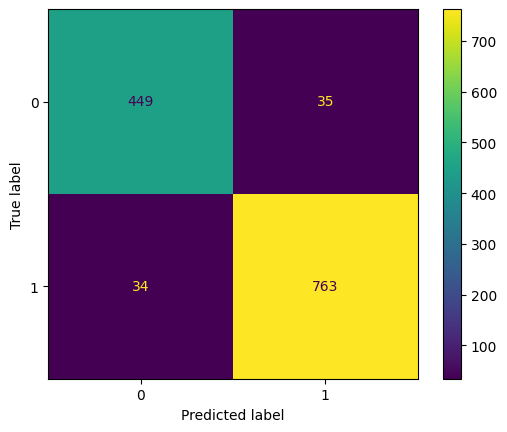

------------------------------------------
knn
dataset :Traning Dataset
Accuracy Score : 1.0
F1 Score : 1.0
Recall Score : 1.0
precision Score : 1.0


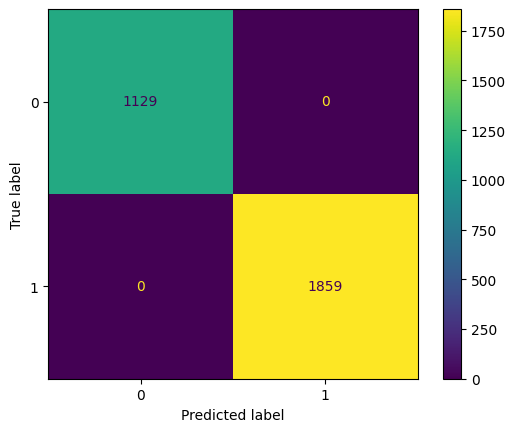

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.9141295862607338
F1 Score : 0.9330900243309003
Recall Score : 0.9623588456712673
precision Score : 0.9055489964580874


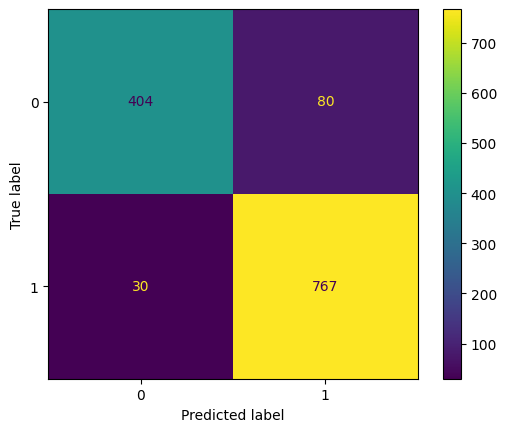

------------------------------------------
random_forest
dataset :Traning Dataset
Accuracy Score : 0.999330655957162
F1 Score : 0.9994623655913979
Recall Score : 1.0
precision Score : 0.99892530897367


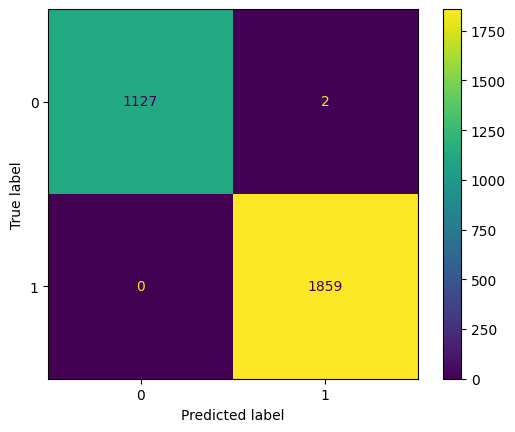

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.9992193598750976
F1 Score : 0.9993730407523511
Recall Score : 1.0
precision Score : 0.9987468671679198


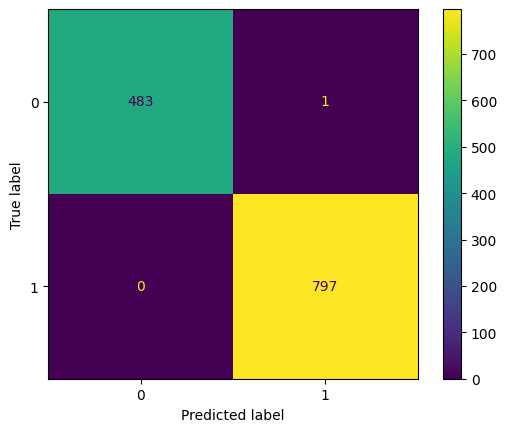

------------------------------------------
XGB_clf
dataset :Traning Dataset
Accuracy Score : 0.998995983935743
F1 Score : 0.9991928974979822
Recall Score : 0.9989241527703067
precision Score : 0.9994617868675996


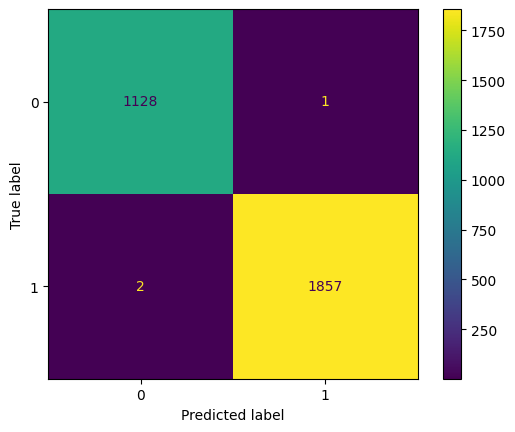

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.9976580796252927
F1 Score : 0.9981191222570532
Recall Score : 0.998745294855709
precision Score : 0.9974937343358395


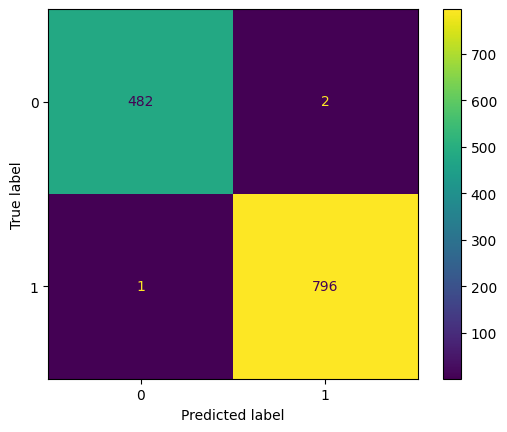

------------------------------------------


In [267]:
Evaluate_Model(Models_info,x_train_transformed,y_train,
                  x_test=x_test_transformed,y_test=y_test)

## Observation
Random Forest is the best Model

# 12. Feature Importance

In [268]:
random_forest.fit(x_train_transformed, y_train)

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(feature_importance)

cibil_score                 0.844179
loan_term                   0.057151
loan_to_income              0.051361
loan_to_total_assests       0.021562
annual_loan_burden          0.012132
total_assests_to_income     0.004675
loan_amount                 0.002166
income_annum                0.001389
luxury_assets_value         0.001232
total_assests               0.001111
residential_assets_value    0.000897
commercial_assets_value     0.000821
bank_asset_value            0.000759
no_of_dependents            0.000414
education                   0.000113
self_employed               0.000038
dtype: float64


dataset :Random Forest Without CIBIL
Accuracy Score : 0.6026541764246682
F1 Score : 0.7273701124799143
Recall Score : 0.8519447929736512
precision Score : 0.6345794392523364


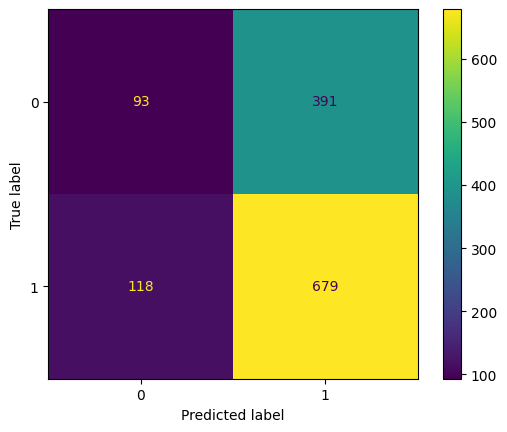

------------------------------------------


In [271]:
x_no_cibil = x.drop("cibil_score", axis=1)

x_train_nc, x_test_nc, y_train_nc, y_test_nc = train_test_split(
    x_no_cibil,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

rf_nc = RandomForestClassifier(
    random_state=42,
    n_estimators=280,
    min_samples_split=9,
    min_samples_leaf=3,
    max_features=0.5,
    max_depth=16,
    bootstrap=True
)

rf_nc.fit(x_train_nc, y_train_nc)

y_pred_nc = rf_nc.predict(x_test_nc)

View_Results(
    "Random Forest Without CIBIL",
    y_test_nc,
    y_pred_nc
)

## observation
CIBIL score was the dominant predictor in the Random Forest model, accounting for approximately 84.4% of the model's feature importance. Removing CIBIL score reduced test accuracy from approximately 99.9% to 60.3%, demonstrating that the model's predictive performance is strongly dependent on this feature